#***SVM***

This notebook trains and evaluates a SVM model for underwater acoustic classification.

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Import libraries:

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import joblib

Mount Drive:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Define Path:

In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/Underwater Audio Data")

DATA_DIR = PROJECT_DIR / "scaled"

MODEL_DIR = PROJECT_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

Load Data:

In [4]:
X_train = pd.read_csv(DATA_DIR / "X_train_scaled.csv")

X_test = pd.read_csv(DATA_DIR / "X_test_scaled.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv")

y_test = pd.read_csv(DATA_DIR / "y_test.csv")

Converts labels to series:

In [5]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

Verify Shape:

In [6]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (6086, 155)
Testing Features : (1811, 155)

Training Labels : (6086,)
Testing Labels : (1811,)


Create the model:

In [7]:
model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

Train the model:

In [8]:
model.fit(
    X_train,
    y_train
)

SVC(class_weight='balanced', random_state=42)

Make predictions:

In [9]:
y_pred = model.predict(X_test)

Accuracy:

In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8487


Precision, Recall, F1-score:

In [11]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Precision : 0.8613
Recall    : 0.8487
F1 Score  : 0.8476


Classification Report:

In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Ambience       0.74      0.59      0.66       360
  Biological       0.73      0.97      0.84       500
     Vessels       0.98      0.88      0.93       951

    accuracy                           0.85      1811
   macro avg       0.82      0.82      0.81      1811
weighted avg       0.86      0.85      0.85      1811



Confusion matrix:

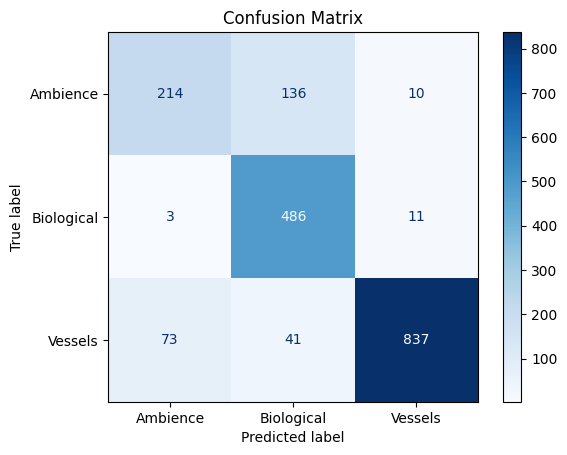

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Saave the model:

In [14]:
joblib.dump(
    model,
    MODEL_DIR / "SVM.pkl"
)

print("Model saved successfully.")

Model saved successfully.


FINAL SUMMARY

In [15]:
print("=" * 60)

print("SUPPORT VECTOR MACHINE COMPLETED")

print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print()

print("Model saved to:")

print(MODEL_DIR / "SVM.pkl")

SUPPORT VECTOR MACHINE COMPLETED
Accuracy : 0.8487
Precision: 0.8613
Recall   : 0.8487
F1 Score : 0.8476

Model saved to:
/content/drive/MyDrive/Underwater Audio Data/models/SVM.pkl
